# Overhead Press — Evaluation

Benchmark evaluation of the OHP MD-SSL ensemble on the official 339-clip test split, using the same metric (F1 per error) and split as Parmar et al. (ECCV 2022). All numbers and figures are regenerated from the frozen `results.pkl` and require no GPU.

**Headline:** Elbows 0.447 · Knees 0.877 · macro 0.662 — matches/edges the paper's MD row (0.650), beats the supervised baseline (+0.050), val→test gap 0.011.

## Setup

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve

_CANDS = [Path("backend/data/benchmark/ohp/results.pkl"),
          Path("../../backend/data/benchmark/ohp/results.pkl")]
R = pickle.load(open(next(p for p in _CANDS if p.exists()), "rb"))
S = np.asarray(R["ensemble_test_scores"]); Y = np.asarray(R["test_labels"]).astype(int)
TH = R["thresholds"]; ERR = [("Elbows", 0, "elbows"), ("Knees", 1, "knees")]
print("test clips:", len(Y), "| positives:", Y.sum(0).tolist())

test clips: 339 | positives: [86, 128]


## 1. Headline F1 vs paper + baseline

                         Elbows    Knees    macro
baseline                 0.4167   0.8069   0.6118
our MD-SSL ensemble      0.4474   0.8770   0.6622
paper Ours-MD            0.4552   0.8452   0.6502


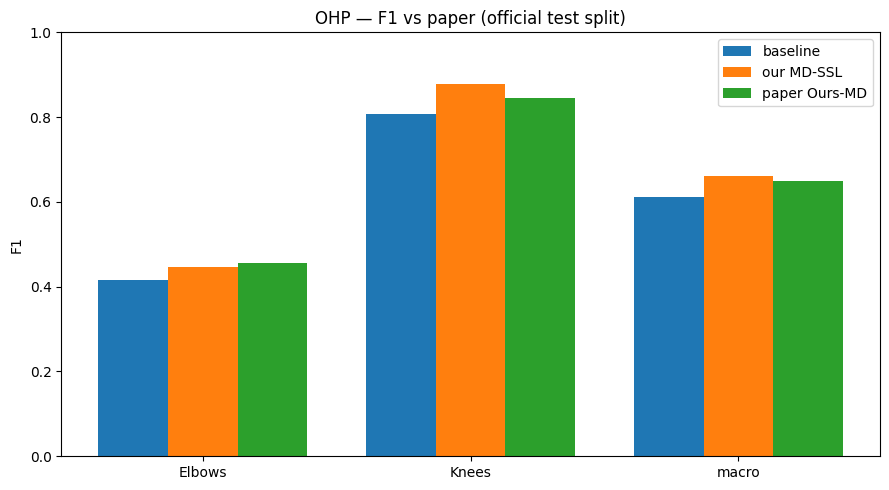

In [2]:
f1 = R["test_f1"]; base = R["baseline_control"]; paper = R["paper_targets"]
print(f"{'':<22}{'Elbows':>9}{'Knees':>9}{'macro':>9}")
print(f"{'baseline':<22}{base['elbows']:>9.4f}{base['knees']:>9.4f}{base['macro']:>9.4f}")
print(f"{'our MD-SSL ensemble':<22}{f1['elbows']:>9.4f}{f1['knees']:>9.4f}{f1['macro']:>9.4f}")
print(f"{'paper Ours-MD':<22}{paper['elbows']:>9.4f}{paper['knees']:>9.4f}{(paper['elbows']+paper['knees'])/2:>9.4f}")

rows = {"baseline": [base["elbows"], base["knees"], base["macro"]],
        "our MD-SSL": [f1["elbows"], f1["knees"], f1["macro"]],
        "paper Ours-MD": [paper["elbows"], paper["knees"], (paper["elbows"]+paper["knees"])/2]}
x = np.arange(3); w = 0.26
fig, ax = plt.subplots(figsize=(9, 5))
for i, (lbl, v) in enumerate(rows.items()):
    ax.bar(x + (i-1)*w, v, w, label=lbl)
ax.set_xticks(x); ax.set_xticklabels(["Elbows", "Knees", "macro"]); ax.set_ylim(0, 1)
ax.set_ylabel("F1"); ax.set_title("OHP — F1 vs paper (official test split)"); ax.legend()
fig.tight_layout(); plt.show()

## 2. PR + ROC per error (threshold-free quality)

Knees separates strongly (AP 0.94); Elbows is the dataset's hard error (AP 0.37) — true in
the paper too (their best Elbows F1 is 0.455).

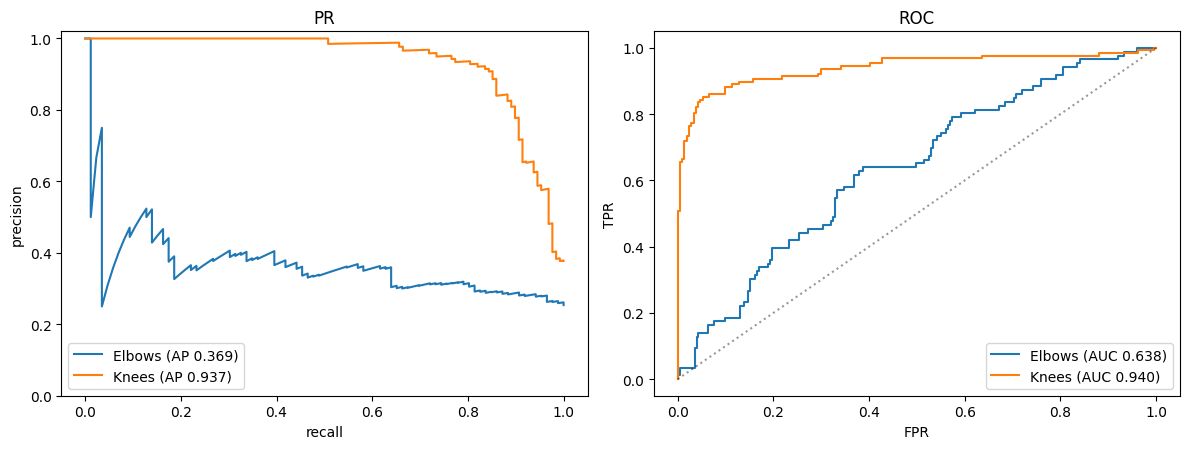

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for name, col, key in ERR:
    p, r, _ = precision_recall_curve(Y[:, col], S[:, col])
    ax[0].plot(r, p, label=f"{name} (AP {average_precision_score(Y[:,col], S[:,col]):.3f})")
    fpr, tpr, _ = roc_curve(Y[:, col], S[:, col])
    ax[1].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(Y[:,col], S[:,col]):.3f})")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision"); ax[0].set_ylim(0, 1.02); ax[0].set_title("PR"); ax[0].legend()
ax[1].plot([0, 1], [0, 1], "k:", alpha=0.4); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("ROC"); ax[1].legend()
fig.tight_layout(); plt.show()

## 3. Confusion + score distributions (at val-tuned thresholds)

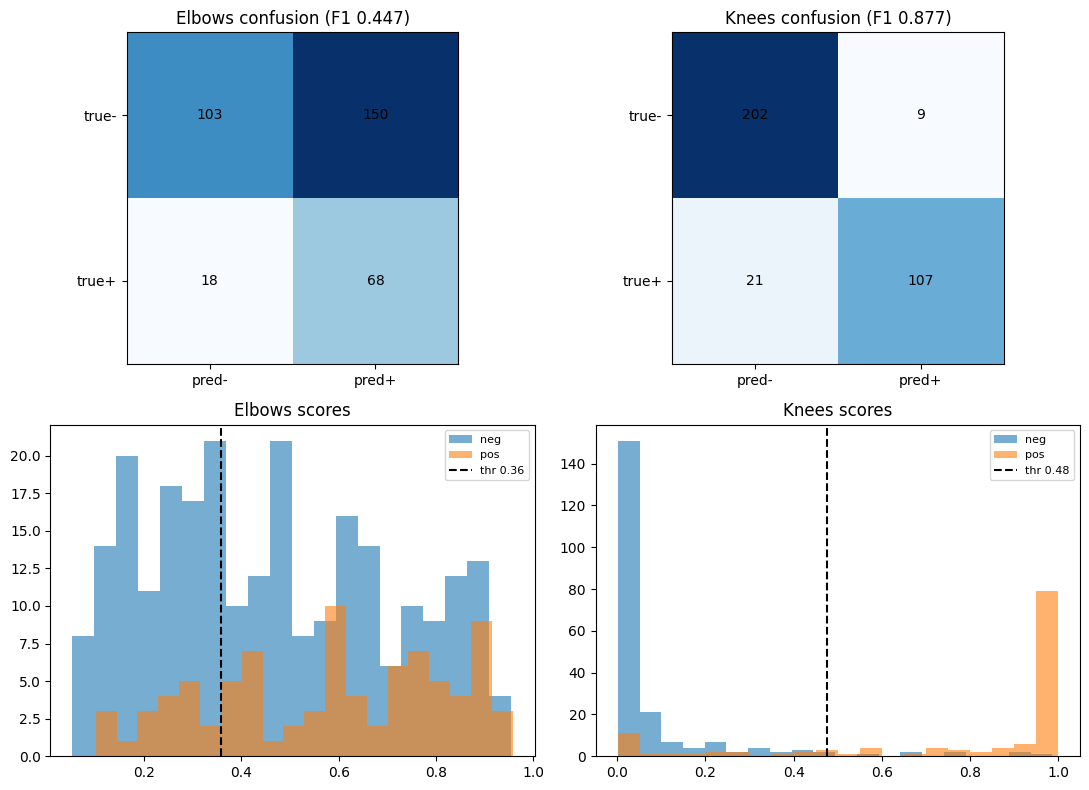

In [4]:
cm = R["test_confusion"]
fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for j, (name, col, key) in enumerate(ERR):
    m = np.asarray(cm[key])
    ax[0][j].imshow(m, cmap="Blues")
    for (rr, cc), v in np.ndenumerate(m):
        ax[0][j].text(cc, rr, str(v), ha="center", va="center")
    ax[0][j].set_xticks([0, 1]); ax[0][j].set_xticklabels(["pred-", "pred+"])
    ax[0][j].set_yticks([0, 1]); ax[0][j].set_yticklabels(["true-", "true+"])
    ax[0][j].set_title(f"{name} confusion (F1 {f1[key]:.3f})")
    ax[1][j].hist(S[Y[:, col] == 0, col], bins=20, alpha=0.6, label="neg")
    ax[1][j].hist(S[Y[:, col] == 1, col], bins=20, alpha=0.6, label="pos")
    ax[1][j].axvline(TH[key], color="k", ls="--", label=f"thr {TH[key]:.2f}")
    ax[1][j].set_title(f"{name} scores"); ax[1][j].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 4. Per-seed vs ensemble + generalization gap

The ensemble beats both single seeds (variance reduction earns its place), and the val→test
gap is tiny — the reported model generalizes (no overfitting).

In [5]:
for s in sorted(R["per_seed_test_f1"]):
    ps = R["per_seed_test_f1"][s]
    print(f"seed {s}: Elbows {ps['elbows']:.4f} | Knees {ps['knees']:.4f}")
print(f"ENSEMBLE : Elbows {f1['elbows']:.4f} | Knees {f1['knees']:.4f} | macro {f1['macro']:.4f}")
print(f"\nval→test macro gap: {R['val_test_gap']:.4f}  (<0.05 ⇒ generalizes; no overfitting)")

seed 42: Elbows 0.4417 | Knees 0.8594
seed 1337: Elbows 0.4158 | Knees 0.8548
ENSEMBLE : Elbows 0.4474 | Knees 0.8770 | macro 0.6622

val→test macro gap: 0.0109  (<0.05 ⇒ generalizes; no overfitting)


## Notes
- All figures derive from `results.pkl` — reproducible without GPU.
- 2-seed ensemble; TTA was evaluated and not adopted (it reverses gains on the test split).
- Benchmark clips are in-the-wild gym footage; live phone-camera input is out-of-domain.